# Distribution Diagnostics for Human and Full-Batch AI Results

This notebook checks how the thesis summary tables are constructed and whether the reported means are distorted by skew.

Key points:
- The text-level tables in the thesis use simple means over 189 texts per condition.
- The pairwise tables use simple means over 189 aligned Advanced-to-simplified pairs per condition.
- The goal here is not to replace the means, but to inspect spread, skew, and median-vs-mean behavior.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    PROJECT_ROOT = ROOT.parent
else:
    PROJECT_ROOT = ROOT

OUT = PROJECT_ROOT / 'outputs'
DIAG = OUT / 'distribution_diagnostics'

text_summary = pd.read_csv(DIAG / 'text_metric_distribution_summary.csv')
pairwise_summary = pd.read_csv(DIAG / 'pairwise_distribution_summary.csv')

text_summary.head(), pairwise_summary.head()

(            group                             metric     mean   median  \
 0  Human Advanced           Age of acquisition (AoA)  359.450  361.404   
 1  Human Advanced  Overall accessibility score (CLI)   -0.117   -0.145   
 2  Human Advanced          Academic vocabulary proxy    0.096    0.092   
 3  Human Advanced          Reading difficulty (FKGL)   11.131   11.005   
 4  Human Advanced          Vocabulary variety (MTLD)  110.285  109.463   
 
       std   skew      min      max  
 0  28.504 -0.115  288.887  440.894  
 1   0.761  0.170   -1.727    1.717  
 2   0.040  0.696    0.022    0.230  
 3   1.922  0.005    6.398   15.119  
 4  22.683  1.038   65.671  231.572  ,
                       group                         metric    mean  median  \
 0  Human simplified example     Meaning similarity (SBERT)   0.891   0.901   
 1  Human simplified example   Change in age of acquisition -18.507 -18.022   
 2  Human simplified example  Change in accessibility score   0.302   0.308   
 3 

## How the thesis tables are calculated

For each text, the pipeline first computes a document-level metric value, for example AoA, FKGL, MTLD, CLI, or the academic-vocabulary proxy.

The thesis table then reports the arithmetic mean of those 189 document-level values for each condition:
- Human Advanced
- Human Elementary
- AI version A (Few-shot 0.5)
- AI version B (Zero-shot 0.0)

For pairwise comparisons, the pipeline first computes one delta per aligned text pair, for example `delta_fk_grade = simplified - advanced`, and then averages those 189 deltas.

In [2]:
text_table = text_summary[['group', 'metric', 'mean', 'median', 'std', 'skew']].copy()
text_table = text_table.round({'mean': 3, 'median': 3, 'std': 3, 'skew': 3})
text_table

,group,metric,mean,median,std,skew
0,Human Advanced,Age of acquisition (AoA),359.450,361.404,28.504,-0.115
1,Human Advanced,Overall accessibility score (CLI),-0.117,-0.145,0.761,0.170
2,Human Advanced,Academic vocabulary proxy,0.096,0.092,0.040,0.696
3,Human Advanced,Reading difficulty (FKGL),11.131,11.005,1.922,0.005
4,Human Advanced,Vocabulary variety (MTLD),110.285,109.463,22.683,1.038
5,Human Advanced,Dictionary coverage,0.511,0.515,0.051,0.120
6,Human Elementary,Age of acquisition (AoA),340.944,340.818,31.636,-0.051
7,Human Elementary,Overall accessibility score (CLI),0.185,0.112,0.885,0.218
8,Human Elementary,Academic vocabulary proxy,0.069,0.065,0.034,0.780
9,Human Elementary,Reading difficulty (FKGL),8.156,8.071,1.397,0.365


## Text-level interpretation

What to look for:
- If the mean and median are close, the distribution is usually reasonably balanced.
- Positive skew means a longer right tail.
- Negative skew means a longer left tail.

In the current outputs:
- **AoA** is only mildly skewed, so the mean is a stable summary.
- **FKGL** is also not strongly skewed.
- **CLI** is only mildly skewed.
- **Academic vocabulary proxy** is moderately right-skewed.
- **MTLD** is the most skewed text-level metric, so it is useful to inspect its spread visually instead of relying on the mean alone.

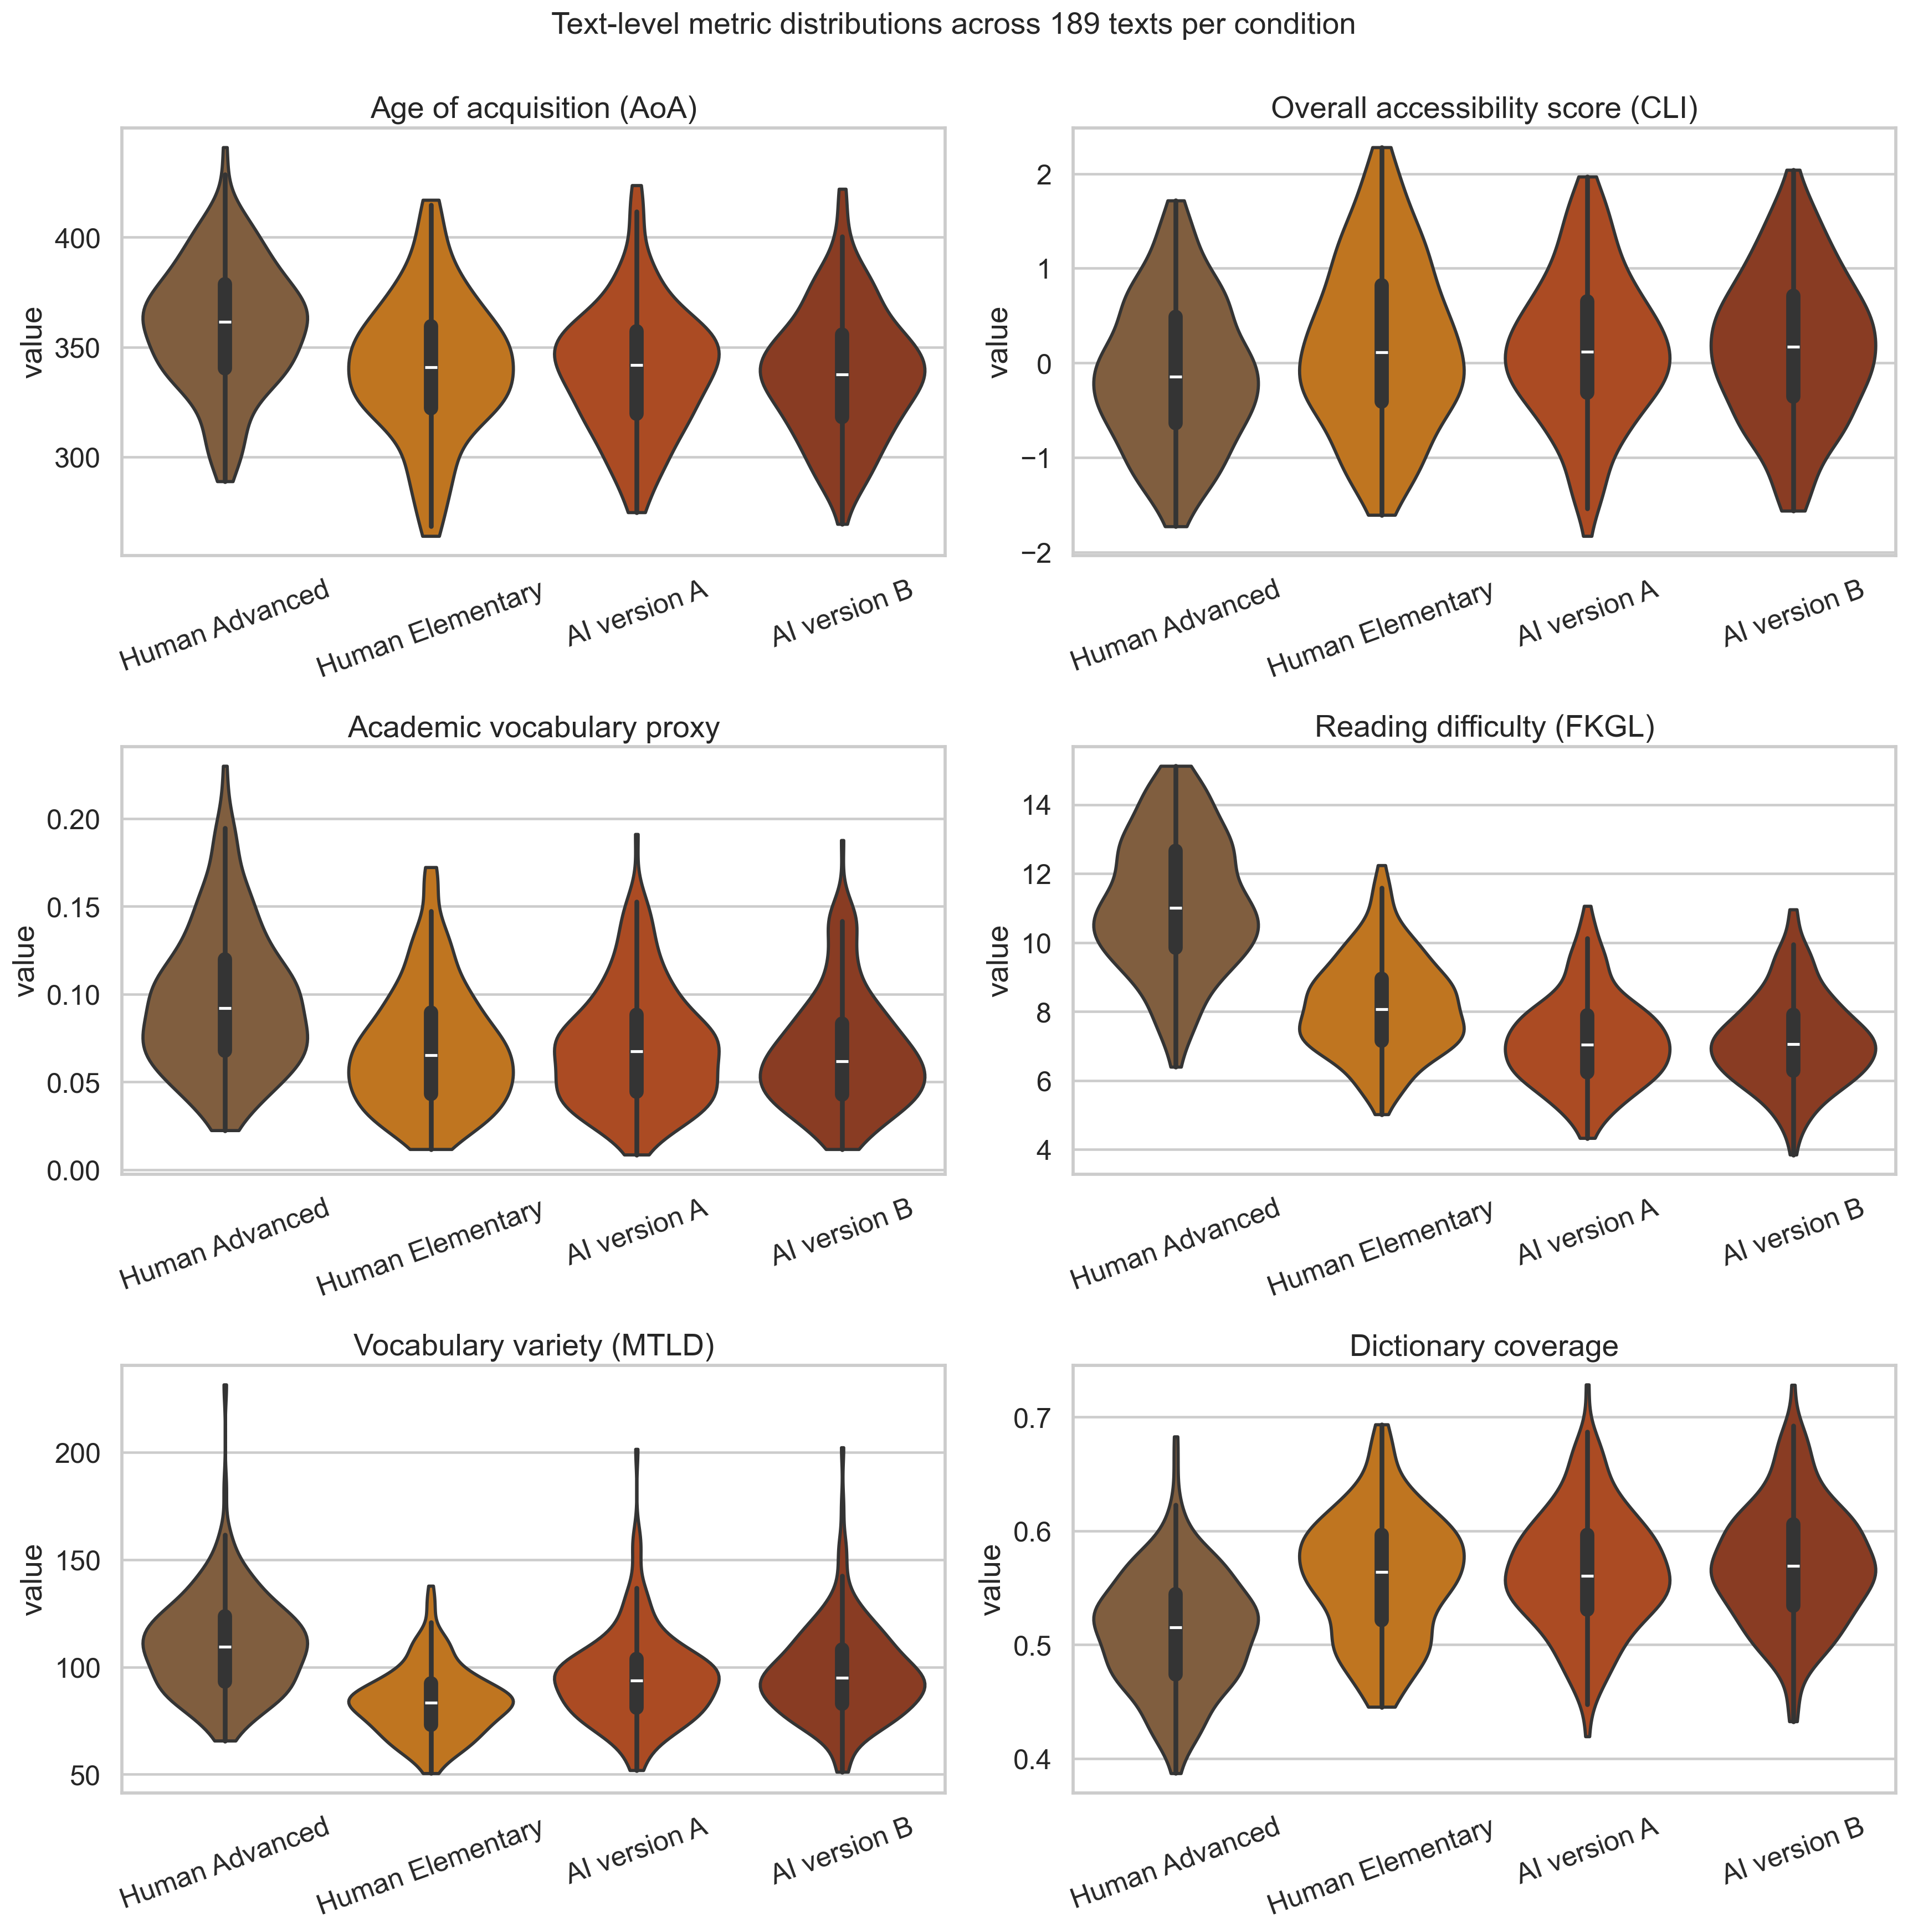

In [3]:
display(Image(filename=str(DIAG / 'text_metric_distributions.png')))

## Pairwise summary table

In [4]:
pairwise_table = pairwise_summary[['group', 'metric', 'mean', 'median', 'std', 'skew']].copy()
pairwise_table = pairwise_table.round({'mean': 3, 'median': 3, 'std': 3, 'skew': 3})
pairwise_table

,group,metric,mean,median,std,skew
0,Human simplified example,Meaning similarity (SBERT),0.891,0.901,0.053,-0.932
1,Human simplified example,Change in age of acquisition,-18.507,-18.022,16.523,-0.651
2,Human simplified example,Change in accessibility score,0.302,0.308,0.369,0.331
3,Human simplified example,Change in reading difficulty,-2.976,-2.761,1.204,-0.653
4,Human simplified example,Change in vocabulary variety,-26.358,-24.284,17.191,-0.976
5,Human simplified example,Change in academic vocabulary proxy,-0.027,-0.025,0.019,-0.597
6,AI version A,Meaning similarity (SBERT),0.902,0.911,0.048,-1.490
7,AI version A,Change in age of acquisition,-19.270,-18.741,12.473,-0.068
8,AI version A,Change in accessibility score,0.315,0.267,0.348,0.030
9,AI version A,Change in reading difficulty,-3.984,-3.870,1.317,-0.380


## Pairwise interpretation

These are the distributions behind the `delta` tables in the thesis.

Important reading points:
- **Meaning similarity (SBERT)** is left-skewed. That is expected because most pairs preserve meaning well, while a smaller number of weaker cases create the tail.
- **Change in reading difficulty** is negative when the text becomes easier. That means a negative mean is desirable here.
- **Change in accessibility score** is positive when the text becomes more accessible. That means a positive mean is desirable here.
- **Change in vocabulary variety** and **change in academic vocabulary proxy** should be interpreted as movement relative to the Advanced source, not as absolute good-or-bad scores by themselves.

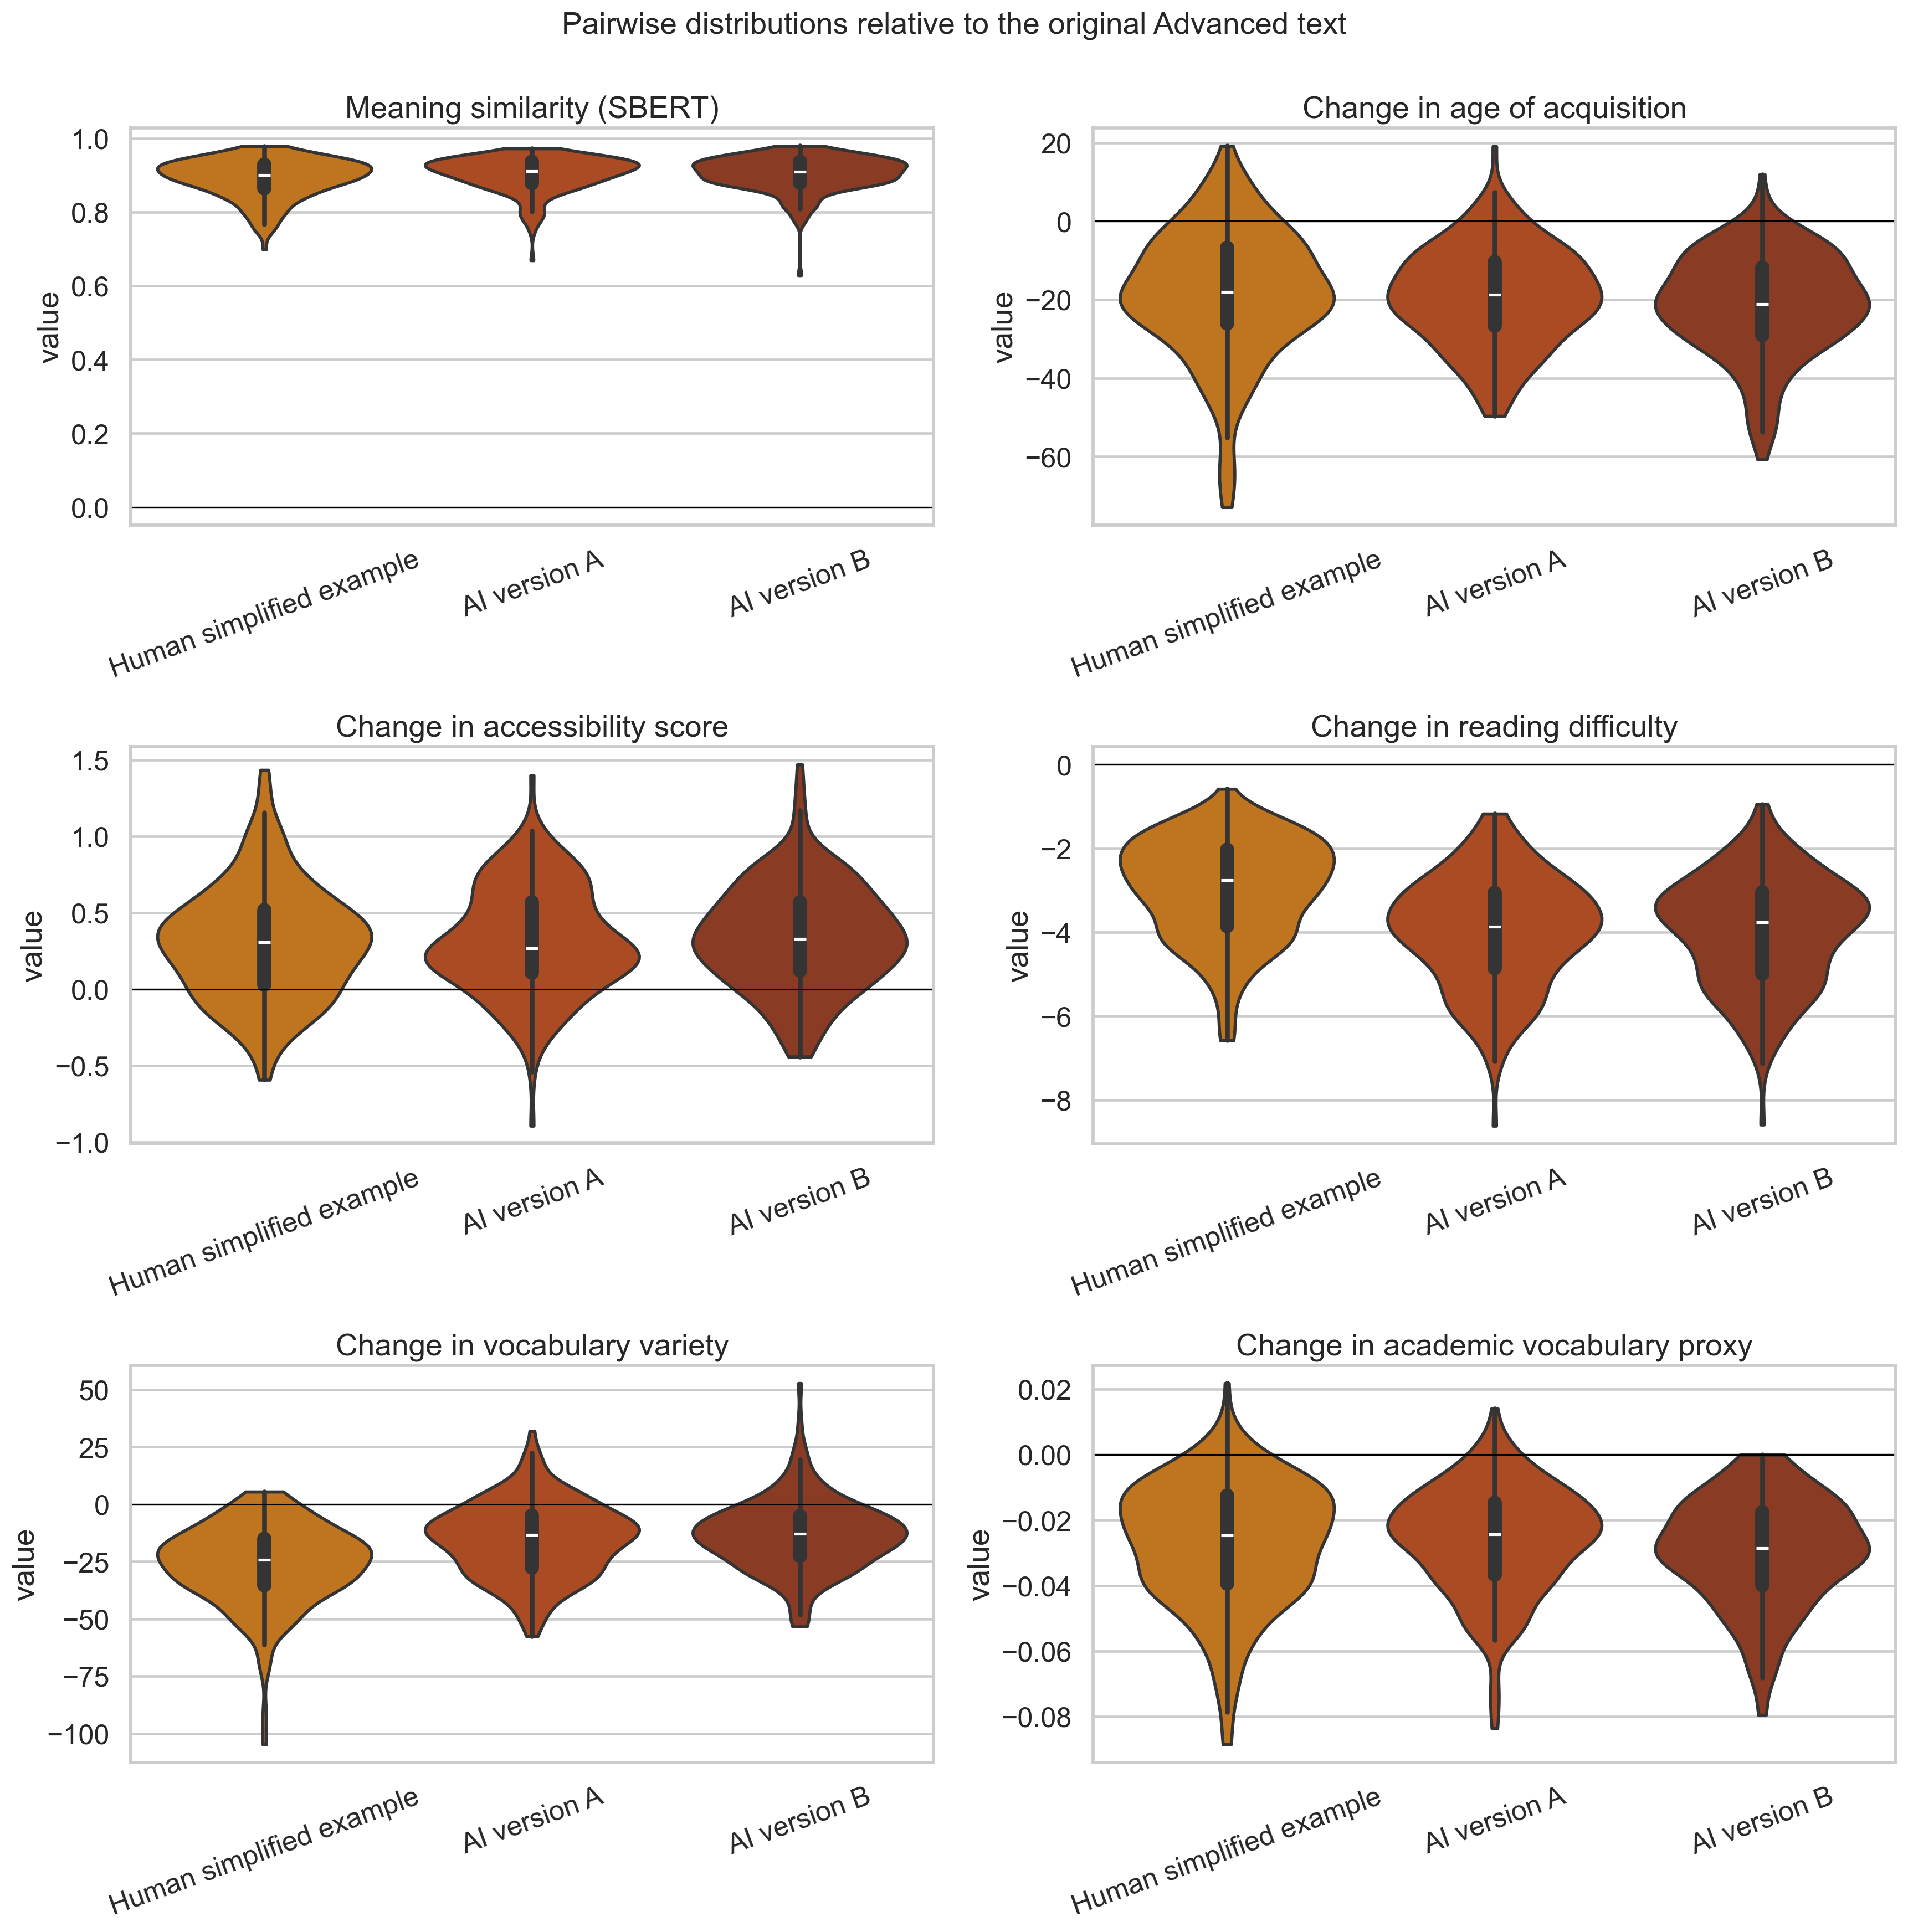

In [5]:
display(Image(filename=str(DIAG / 'pairwise_distributions.png')))

## Thesis-facing conclusion

The thesis can still report means as the primary summary because:
- each condition contains 189 observations,
- AoA, FKGL, and CLI are not strongly skewed,
- the broad pattern is stable across the human and AI conditions.

At the same time, the appendix figures are important because they show that:
- MTLD has a stronger right tail,
- the academic-vocabulary proxy is moderately right-skewed,
- SBERT similarity clusters high with a left tail.

So the correct interpretation is: the mean is acceptable as a compact thesis summary, but it should be read together with the distribution plots for the most skewed metrics.